# CA3: ML

## Preprocess

As you can see below we import data and scan it but there is no Null or Nan or missing value, it seems everything is ok 

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Grades.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (397, 25)


,university,sex,age,address,motherEducation,fatherEducation,motherJob,fatherJob,reason,travelTime,...,internet,romantic,freeTime,goOut,Dalc,Walc,absences,EPSGrade,DSGrade,finalGrade
0,PR,F,18,U,4,4,at_home,teacher,course,2,...,no,no,3,4,1,1,6,5,6,6
1,PR,F,17,U,1,1,at_home,other,course,1,...,yes,no,3,3,1,1,4,5,5,6
2,PR,F,15,U,1,1,at_home,other,other,1,...,yes,no,3,2,2,3,10,7,8,10
3,PR,F,15,U,4,2,health,services,home,1,...,yes,yes,2,2,1,1,2,15,14,15
4,PR,F,16,U,3,3,other,other,home,1,...,no,no,3,2,1,2,4,6,10,10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   university         397 non-null    object
 1   sex                397 non-null    object
 2   age                397 non-null    int64 
 3   address            397 non-null    object
 4   motherEducation    397 non-null    int64 
 5   fatherEducation    397 non-null    int64 
 6   motherJob          397 non-null    object
 7   fatherJob          397 non-null    object
 8   reason             397 non-null    object
 9   travelTime         397 non-null    int64 
 10  studyTime          397 non-null    int64 
 11  failures           397 non-null    int64 
 12  universitySupport  397 non-null    object
 13  paid               397 non-null    object
 14  higher             397 non-null    object
 15  internet           397 non-null    object
 16  romantic           397 non-null    object
 1

In [4]:
df.describe(include="all")

,university,sex,age,address,motherEducation,fatherEducation,motherJob,fatherJob,reason,travelTime,...,internet,romantic,freeTime,goOut,Dalc,Walc,absences,EPSGrade,DSGrade,finalGrade
count,397,397,397.000000,397,397.000000,397.000000,397,397,397,397.000000,...,397,397,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
unique,2,2,NaN,2,NaN,NaN,5,5,4,NaN,...,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,PR,F,NaN,U,NaN,NaN,other,other,course,NaN,...,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,350,209,NaN,308,NaN,NaN,142,217,146,NaN,...,329,265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.705290,NaN,2.748111,2.521411,NaN,NaN,NaN,1.450882,...,NaN,NaN,3.234257,3.108312,1.478589,2.289673,5.695214,10.881612,10.687657,10.377834
std,NaN,NaN,1.279716,NaN,1.097301,1.090672,NaN,NaN,NaN,0.696840,...,NaN,NaN,0.996476,1.112762,0.889143,1.286770,7.988015,3.333120,3.770322,4.604928
min,NaN,NaN,15.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,1.000000,...,NaN,NaN,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,2.000000,2.000000,NaN,NaN,NaN,1.000000,...,NaN,NaN,3.000000,2.000000,1.000000,1.000000,0.000000,8.000000,9.000000,8.000000
50%,NaN,NaN,17.000000,NaN,3.000000,2.000000,NaN,NaN,NaN,1.000000,...,NaN,NaN,3.000000,3.000000,1.000000,2.000000,4.000000,11.000000,11.000000,11.000000
75%,NaN,NaN,18.000000,NaN,4.000000,3.000000,NaN,NaN,NaN,2.000000,...,NaN,NaN,4.000000,4.000000,2.000000,3.000000,8.000000,13.000000,13.000000,14.000000


In [5]:
df.isna().sum()

university           0
sex                  0
age                  0
address              0
motherEducation      0
fatherEducation      0
motherJob            0
fatherJob            0
reason               0
travelTime           0
studyTime            0
failures             0
universitySupport    0
paid                 0
higher               0
internet             0
romantic             0
freeTime             0
goOut                0
Dalc                 0
Walc                 0
absences             0
EPSGrade             0
DSGrade              0
finalGrade           0
dtype: int64

### Fill mising values
we have three ways to predict missing values for numerical and categorical vals:
- using Mean or Median for numerical vals
- using Mode for categorical vals
- using K nearset (KNN) for categorical vals

below you can see implementation of each method but as our data is clean it is not useful

In [6]:

num_cols = df.select_dtypes(include=["int64","float64"]).columns
medians = df[num_cols].median()
df_median = df.copy()
df_median[num_cols] = df_median[num_cols].fillna(medians)


cat_cols = df.select_dtypes(include=["object"]).columns
modes = {c: df[c].mode()[0] for c in cat_cols}
df_mode = df.copy()
for c in cat_cols:
    df_mode[c] = df_mode[c].fillna(modes[c])


col_to_fill = "studyTime"
k = 5
feature_cols = [c for c in num_cols if c != "studyTime"]

df_knn = df.copy()
miss_idx = df_knn[df_knn[col_to_fill].isna()].index
complete = df_knn[df_knn[col_to_fill].notna()]
complete = complete.dropna(subset=feature_cols)
    
for i in miss_idx:
    row_feat = df_knn.loc[i, feature_cols]
    if row_feat.isna().any():
        continue
    diffs = complete[feature_cols] - row_feat.values
    dists = np.sqrt((diffs**2).sum(axis=1))
    nearest = dists.nsmallest(k).index
    df_knn.at[i, col_to_fill] = complete.loc[nearest, col_to_fill].mean()

### Remove unuseful columns

If you want to omit a column it should be either considerd as unuseful by expert (which decide the atribut can't help to predict the target) which i didn't find any column that is unnecessary or the column doesn't have any use full data for example every row in it has same value (or nearly every row)

here again we don't have such a column so we keep all the columns

In [7]:
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("constant columns:", constant_cols)

near_constant = []
for c in df.columns:
    top_freq = df[c].value_counts(normalize=True).iloc[0]
    if top_freq >= 0.98:
        near_constant.append(c)
print("near constant columns:", near_constant)

to_drop = list(set(constant_cols + near_constant))
print("will consider dropping:", to_drop)
df = df.drop(columns=to_drop)

constant columns: []
near constant columns: []
will consider dropping: []


In [8]:
binary_mappings = {
    "sex":      {"F": 0, "M": 1},
    "universitySupport": {"no": 0, "yes": 1},
    "paid":     {"no": 0, "yes": 1},
    "higher":   {"no": 0, "yes": 1},
    "internet": {"no": 0, "yes": 1},
    "romantic": {"no": 0, "yes": 1},
    "university": {"PR": 0, "CM": 1},
    "address": {"R": 0, "U": 1},
    "fatherJob": {"other": 0, "teacher": 1, "health": 2, "services": 3, "at_home": 4},
    "motherJob": {"other": 0, "teacher": 1, "health": 2, "services": 3, "at_home": 4},
    "reason": {"other": 0, "reputation": 1, "home": 2, "course": 3},
}

for col, mapping in binary_mappings.items():
    df[col] = df[col].map(mapping)

df.head()

,university,sex,age,address,motherEducation,fatherEducation,motherJob,fatherJob,reason,travelTime,...,internet,romantic,freeTime,goOut,Dalc,Walc,absences,EPSGrade,DSGrade,finalGrade
0,0,0,18,1,4,4,4,1,3,2,...,0,0,3,4,1,1,6,5,6,6
1,0,0,17,1,1,1,4,0,3,1,...,1,0,3,3,1,1,4,5,5,6
2,0,0,15,1,1,1,4,0,0,1,...,1,0,3,2,2,3,10,7,8,10
3,0,0,15,1,4,2,2,3,2,1,...,1,1,2,2,1,1,2,15,14,15
4,0,0,16,1,3,3,0,0,2,1,...,0,0,3,2,1,2,4,6,10,10


In [9]:
def grade_bin(x):
    if x > 17:     return "A"
    elif x >= 14:  return "B"
    elif x >= 10:  return "C"
    else:          return "Fail"

df["finalGrade_cat"] = df["finalGrade"].apply(grade_bin)
df["finalGrade_cat"].value_counts()

finalGrade_cat
C       165
Fail    132
B        82
A        18
Name: count, dtype: int64

## Development

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score)
%matplotlib inline
sns.set_theme(style="whitegrid")

### Train-Test Split

In [11]:
X = df.drop(columns=["finalGrade","finalGrade_cat"])
y = df["finalGrade_cat"]

label_encoder_y = LabelEncoder()
y_encoder = label_encoder_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoder, test_size=0.2, random_state=42, stratify=y_encoder)

### Normalization/Standardization

Here I used Z-score normalization. It works by, for each feature, subtracting its mean and dividing by its standard deviation (as learned on the training set).  

Why use it?  
- Puts all numeric features on the same scale (mean = 0, std = 1)  
- Prevents features with larger original ranges from dominating models  
- Speeds up and stabilizes training for many algorithms

In [12]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

### Evaluation

In [13]:
def evaluate_model(name, y_true, y_pred):
    print(f"{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision (macro):", precision_score(y_true, y_pred, average="macro"))
    print("Recall (macro):", recall_score(y_true, y_pred, average="macro"))
    print("F1-score (macro):", f1_score(y_true, y_pred, average="macro"))
    print("Precision (micro):", precision_score(y_true, y_pred, average="micro"))
    print("Recall (micro):", recall_score(y_true, y_pred, average="micro"))
    print("F1-score (micro):", f1_score(y_true, y_pred, average="micro"))
    print("Precision (weighted):", precision_score(y_true, y_pred, average="weighted"))
    print("Recall (weighted):", recall_score(y_true, y_pred, average="weighted"))
    print("F1-score (weighted):", f1_score(y_true, y_pred, average="weighted"))
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_encoder_y.classes_))

Gaussian Naive Bayes
Accuracy: 0.5625
Precision (macro): 0.5297619047619048
Recall (macro): 0.5863320707070707
F1-score (macro): 0.4968438833570412
Precision (micro): 0.5625
Recall (micro): 0.5625
F1-score (micro): 0.5625
Precision (weighted): 0.6858333333333333
Recall (weighted): 0.5625
F1-score (weighted): 0.5783687470365102

Confusion Matrix:


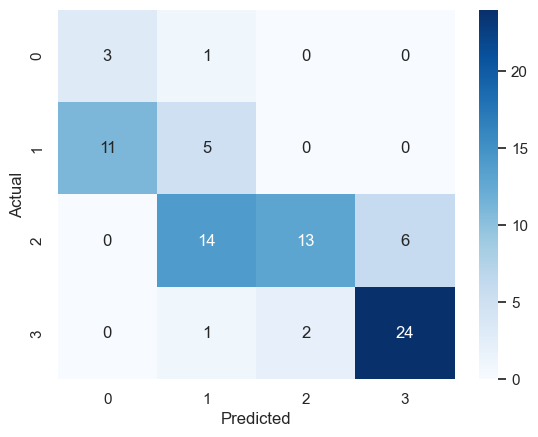


Classification Report:
              precision    recall  f1-score   support

           A       0.21      0.75      0.33         4
           B       0.24      0.31      0.27        16
           C       0.87      0.39      0.54        33
        Fail       0.80      0.89      0.84        27

    accuracy                           0.56        80
   macro avg       0.53      0.59      0.50        80
weighted avg       0.69      0.56      0.58        80



In [14]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
evaluate_model("Gaussian Naive Bayes", y_test, y_pred_nb)

Best DT params: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Decision Tree
Accuracy: 0.875
Precision (macro): 0.881547619047619
Recall (macro): 0.8806292087542088
F1-score (macro): 0.8705899575464793
Precision (micro): 0.875
Recall (micro): 0.875
F1-score (micro): 0.875
Precision (weighted): 0.8850892857142858
Recall (weighted): 0.875
F1-score (weighted): 0.8729212413995022

Confusion Matrix:


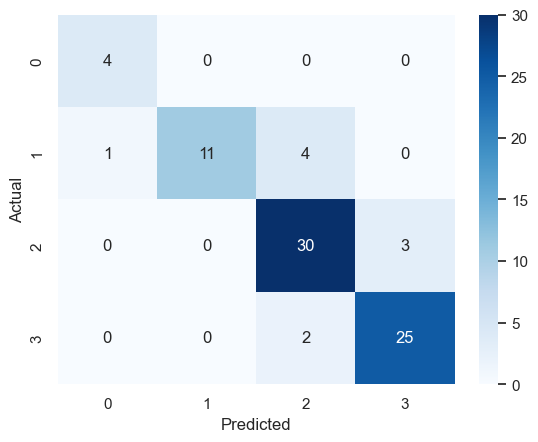


Classification Report:
              precision    recall  f1-score   support

           A       0.80      1.00      0.89         4
           B       1.00      0.69      0.81        16
           C       0.83      0.91      0.87        33
        Fail       0.89      0.93      0.91        27

    accuracy                           0.88        80
   macro avg       0.88      0.88      0.87        80
weighted avg       0.89      0.88      0.87        80



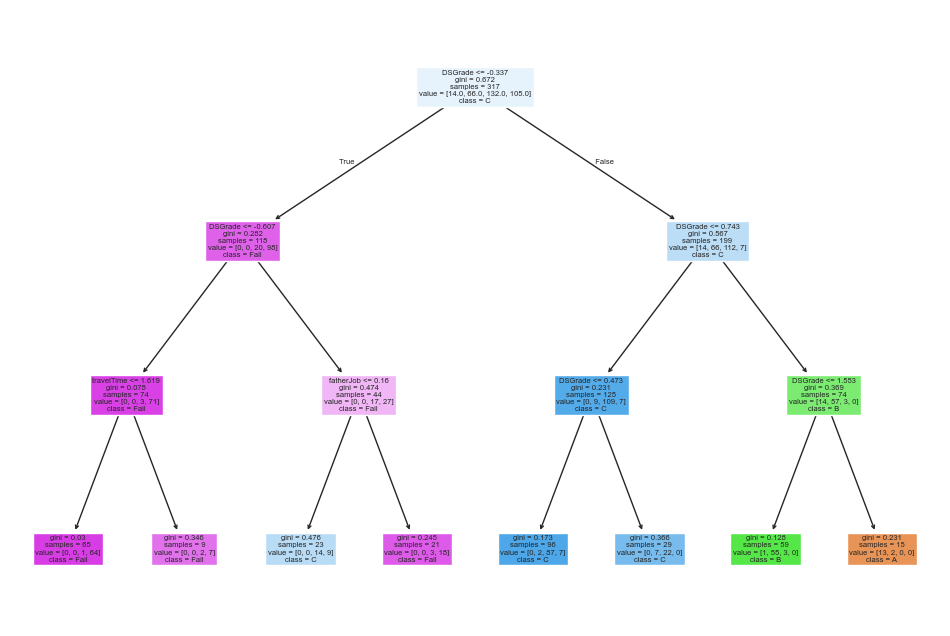

Decision Tree Feature Importances:
 DSGrade       0.964548
fatherJob     0.031045
travelTime    0.004408
paid          0.000000
EPSGrade      0.000000
absences      0.000000
Walc          0.000000
Dalc          0.000000
goOut         0.000000
freeTime      0.000000
dtype: float64


In [15]:
dt = DecisionTreeClassifier(random_state=42)
param_grid = {
    "max_depth": [None, 3, 5, 7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
grid_dt = GridSearchCV(dt, param_grid, cv=5, scoring="accuracy")
grid_dt.fit(X_train, y_train)
print("Best DT params:", grid_dt.best_params_)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
evaluate_model("Decision Tree", y_test, y_pred_dt)

plt.figure(figsize=(12,8))
plot_tree(best_dt, feature_names=X.columns, class_names=label_encoder_y.classes_, filled=True)
plt.show()

fi = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Decision Tree Feature Importances:\n", fi.head(10))

Best RF params: {'n_estimators': 50, 'max_features': None, 'max_depth': None}
Random Forest
Accuracy: 0.8875
Precision (macro): 0.888423645320197
Recall (macro): 0.889888468013468
F1-score (macro): 0.8786570183629008
Precision (micro): 0.8875
Recall (micro): 0.8875
F1-score (micro): 0.8875
Precision (weighted): 0.8961576354679803
Recall (weighted): 0.8875
F1-score (weighted): 0.8847708527855586

Confusion Matrix:


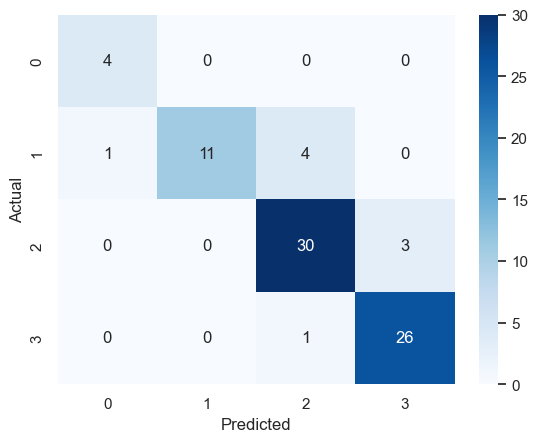


Classification Report:
              precision    recall  f1-score   support

           A       0.80      1.00      0.89         4
           B       1.00      0.69      0.81        16
           C       0.86      0.91      0.88        33
        Fail       0.90      0.96      0.93        27

    accuracy                           0.89        80
   macro avg       0.89      0.89      0.88        80
weighted avg       0.90      0.89      0.88        80



In [16]:
rf = RandomForestClassifier(random_state=42)
param_dist = {
    "n_estimators": [50,100,200],
    "max_depth": [None,5,10],
    "max_features": [None,"sqrt","log2"]
}
rand_rf = RandomizedSearchCV(rf, param_dist, n_iter=6, cv=5, scoring="accuracy", random_state=42, error_score="raise")
rand_rf.fit(X_train, y_train)
print("Best RF params:", rand_rf.best_params_)

best_rf = rand_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
evaluate_model("Random Forest", y_test, y_pred_rf)

Best XGB params: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 50}
XGBoost
Accuracy: 0.9
Precision (macro): 0.9375
Recall (macro): 0.9118792087542088
F1-score (macro): 0.9219988936013277
Precision (micro): 0.9
Recall (micro): 0.9
F1-score (micro): 0.9
Precision (weighted): 0.9049107142857142
Recall (weighted): 0.9
F1-score (weighted): 0.9000991148810622

Confusion Matrix:


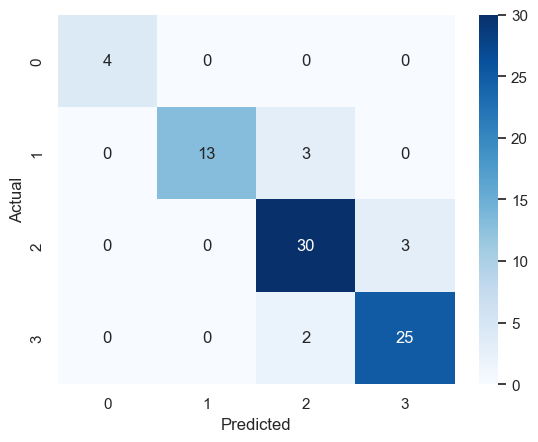


Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      0.81      0.90        16
           C       0.86      0.91      0.88        33
        Fail       0.89      0.93      0.91        27

    accuracy                           0.90        80
   macro avg       0.94      0.91      0.92        80
weighted avg       0.90      0.90      0.90        80



In [17]:
xgb = XGBClassifier(random_state=42, verbosity=0, eval_metric="mlogloss")

param_grid_xgb = {
    "learning_rate":    [0.01, 0.1, 0.2],
    "n_estimators":     [50, 100, 200],    
    "max_depth":        [3, 5, 7],          
    "min_child_weight": [1, 3, 5],       
    "colsample_bytree": [0.6, 0.8, 1.0] 
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=3, scoring="accuracy", error_score="raise", n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print("Best XGB params:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
evaluate_model("XGBoost", y_test, y_pred_xgb)

## Scratch Decision Tree

In [18]:
class ScratchDecisionTreeClassifier:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):
        data = np.column_stack((X.values, y))
        self.n_features = X.shape[1]
        self.feature_names = X.columns.tolist()
        self.tree = self._build_tree(data, depth=0)
        return self

    def _build_tree(self, data, depth):
        X, y = data[:, :-1], data[:, -1]
        num_samples, num_feats = X.shape

        if len(np.unique(y)) == 1 or depth == self.max_depth or num_samples < 2:
            leaf_value = self._majority_class(y)
            return {"type":"leaf", "class":leaf_value}

        feat_idx, thr = self._best_split(data)
        if feat_idx is None:
            return {"type":"leaf", "class": self._majority_class(y)}

        left = data[X[:, feat_idx] <= thr]
        right = data[X[:, feat_idx] > thr]

        left_node  = self._build_tree(left, depth+1)
        right_node = self._build_tree(right, depth+1)
        return {
            "type":"node",
            "feature": feat_idx,
            "threshold": thr,
            "left": left_node,
            "right": right_node
        }

    def _best_split(self, data):
        X, y = data[:, :-1], data[:, -1]
        best_gain, best_idx, best_thr = 0, None, None
        parent_gini = self._gini(y)

        for feat in range(self.n_features):
            values = np.unique(X[:, feat])
            for thr in values:
                left_y  = y[X[:, feat] <= thr]
                right_y = y[X[:, feat] > thr]
                if len(left_y)==0 or len(right_y)==0:
                    continue
                gain = parent_gini - (
                    len(left_y)/len(y)*self._gini(left_y)
                    + len(right_y)/len(y)*self._gini(right_y)
                )
                if gain > best_gain:
                    best_gain, best_idx, best_thr = gain, feat, thr
        return best_idx, best_thr

    def _gini(self, y):
        _, counts = np.unique(y, return_counts=True)
        probs = counts / counts.sum()
        return 1 - np.sum(probs**2)

    def _majority_class(self, y):
        vals, counts = np.unique(y, return_counts=True)
        return vals[np.argmax(counts)]

    def predict(self, X):
        return np.array([self._predict_row(row, self.tree) for row in X.values])

    def _predict_row(self, row, node):
        if node["type"] == "leaf":
            return node["class"]
        if row[node["feature"]] <= node["threshold"]:
            return self._predict_row(row, node["left"])
        else:
            return self._predict_row(row, node["right"])

In [19]:
scratch = ScratchDecisionTreeClassifier(max_depth=5)
scratch.fit(X_train, y_train)
y_pred_scratch = scratch.predict(X_test)

scratch_acc = (y_pred_scratch == y_test).mean()
print(f"Scratch Tree Accuracy: {scratch_acc:.3f}")

Scratch Tree Accuracy: 0.887


In [20]:
sklearn_acc = accuracy_score(y_test, best_dt.predict(X_test))
print(f"scikit-learn Tree Accuracy: {sklearn_acc:.3f}")

scikit-learn Tree Accuracy: 0.875


In [21]:
new_student = {
    "university": 0, "sex": 1, "age": 22,
    "address":1, "motherEducation":4, "fatherEducation":4,
    "motherJob":4, "fatherJob":0, "reason":3,
    "travelTime":2, "studyTime":2, "failures":0,
    "universitySupport":0, "paid":0, "higher":1,
    "internet":1, "romantic":0, "freeTime":1,
    "goOut":2, "Dalc":1, "Walc":1,
    "absences": 3, "EPSGrade":17, "DSGrade":20
}

new_df = pd.DataFrame([new_student])
new_df[num_cols] = scaler.transform(new_df[num_cols])

final_pred = best_xgb.predict(new_df)
print("Predicted finalGrade_cat:", label_encoder_y.inverse_transform(final_pred)[0])

Predicted finalGrade_cat: A
